With slight additions, the code for this baseline was taken from a tutorial by Sterbak (2018) at https://www.depends-on-the-definition.com/lstm-with-char-embeddings-for-ner/ and is provided under the MIT-license

In [ ]:
from google.colab import files
uploaded = files.upload()

Saving PV_DATASET_COLAB.csv to PV_DATASET_COLAB.csv


load data set to lists in order to access all tokens (without this a part of the data set is lost)

In [ ]:
list1 = list()
list2 = list()
list3 = list()

In [ ]:
import pandas as pd
import numpy as np

In [ ]:
fil = open('dataset_fine_tuning.csv', 'r', encoding='utf8')
lines = fil.readlines()
for line in lines:
  line = line.split()
  list1.append(line[0])
  list2.append(line[1])
  list3.append(line[2])

data = pd.DataFrame(list(zip(list1, list2, list3)),
                columns =['id', 'token', 'tag'])

In [ ]:
len(data)

157565

In [ ]:
data.tail(10)

,id,token,tag
157555,6358,together,NO
157556,6358,to,NO
157557,6358,serve,NO
157558,6358,the,NO
157559,6358,common,NO
157560,6358,good,NO
157561,6358,of,NO
157562,6358,old,NO
157563,6358,people,NO
157564,6358,.,NO


extract tokens

In [ ]:
words = list(set(data["token"].values))
n_words = len(words); n_words

14764

extract tags

In [ ]:
tags = list(set(data["tag"].values))
n_tags = len(tags); n_tags
print(tags)

['NO', 'YES']


In [ ]:
class SentenceGetter(object):

    def __init__(self, data):
        self.n_sent = 1
        self.data = data
        self.empty = False
        agg_func = lambda s: [(w, t) for w, t in zip(s["token"].values.tolist(),
                                                           s["tag"].values.tolist())]
        self.grouped = self.data.groupby("id").apply(agg_func)
        self.sentences = [s for s in self.grouped]

    def get_next(self):
        try:
            s = self.grouped["Sentence: {}".format(self.n_sent)]
            self.n_sent += 1
            return s
        except:
            return None

In [ ]:
getter = SentenceGetter(data)

In [ ]:
sentences = getter.sentences

max len = the length of the longest sentence
max len char = the length of the longest word

In [ ]:
max_len = 108
max_len_char = 18

map indices to tokens and tags

In [ ]:
word2idx = {w: i + 2 for i, w in enumerate(words)}
word2idx["UNK"] = 1
word2idx["PAD"] = 0

In [ ]:
idx2word = {i: w for w, i in word2idx.items()}
tag2idx = {'NO': 0, 'PAD': 0, 'YES': 1}
idx2tag = {0:'NO', 0:'PAD', 1:'YES'}

In [ ]:
print(word2idx["a"])
print(tag2idx["NO"])

6187
0


represent sequences of words with previously added indices

In [ ]:
from keras.preprocessing.sequence import pad_sequences
X_word = [[word2idx[w[0]] for w in s] for s in sentences]

In [ ]:
X_word = pad_sequences(maxlen=max_len, sequences=X_word, value=word2idx["PAD"], padding='post', truncating='post')
print(X_word)

[[ 7589 13877  6187 ...     0     0     0]
 [ 7827  8028  3107 ...     0     0     0]
 [ 3879 12540 10018 ...     0     0     0]
 ...
 [ 4126  6669  4041 ...     0     0     0]
 [10053  9362  7867 ...     0     0     0]
 [ 4985  9095  2278 ...     0     0     0]]


same for characters

In [ ]:
chars = set([w_i for w in words for w_i in w])
n_chars = len(chars)

In [ ]:
char2idx = {c: i + 2 for i, c in enumerate(chars)}
char2idx["UNK"] = 1
char2idx["PAD"] = 0
print(char2idx)

{'£': 2, '’': 3, 'q': 4, 'K': 5, '-': 6, '!': 7, '—': 8, 'z': 9, ',': 10, 'E': 11, 'ç': 12, '"': 13, '…': 14, 's': 15, 'u': 16, 'Z': 17, '6': 18, 'e': 19, 'à': 20, 'C': 21, '3': 22, 'a': 23, ')': 24, 'c': 25, 'P': 26, 'U': 27, '”': 28, 'I': 29, '&': 30, '¥': 31, 'i': 32, 'h': 33, 'D': 34, '`': 35, 'H': 36, '$': 37, 'r': 38, '%': 39, 'p': 40, '[': 41, 'A': 42, 'g': 43, "'": 44, 'o': 45, 'f': 46, 'Y': 47, '|': 48, 'L': 49, 'k': 50, 'M': 51, 'T': 52, 'X': 53, '/': 54, 'F': 55, '–': 56, '°': 57, '·': 58, '?': 59, '2': 60, 'V': 61, 'n': 62, 't': 63, ':': 64, 'á': 65, 'R': 66, '9': 67, '“': 68, '(': 69, 'y': 70, '4': 71, 'W': 72, 'B': 73, '5': 74, '‘': 75, 'm': 76, 'N': 77, 'j': 78, 'G': 79, 'ë': 80, 'ï': 81, 'S': 82, '0': 83, 'ü': 84, 'í': 85, ';': 86, '8': 87, ']': 88, 'Q': 89, 'ö': 90, '.': 91, '€': 92, 'O': 93, 'v': 94, '7': 95, 'J': 96, 'b': 97, 'x': 98, 'w': 99, 'é': 100, 'l': 101, '1': 102, 'd': 103, 'UNK': 1, 'PAD': 0}


In [ ]:
X_char = []
for sentence in sentences:
    sent_seq = []
    for i in range(max_len):
        word_seq = []
        for j in range(max_len_char):
            try:
                word_seq.append(char2idx.get(sentence[i][0][j]))
            except:
                word_seq.append(char2idx.get("PAD"))
        sent_seq.append(word_seq)
    X_char.append(np.array(sent_seq))

In [ ]:
print(np.shape(X_char))

(6359, 108, 18)


same for tags

In [ ]:
y = [[tag2idx[w[1]] for w in s] for s in sentences]
print(y)

[[0, 0, 0, 0, 0], [0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0], [0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0], [0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0], [0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0], [0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0], [0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 1, 1, 0, 0, 0, 0, 1, 1, 1, 0, 0], [0, 0, 0, 0, 0, 0, 0], [0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0], [0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0], [0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0], [0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0], [0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0], [0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0], [0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0

In [ ]:
y = pad_sequences(maxlen=max_len, sequences=y, value=tag2idx["PAD"], padding='post', truncating='post')
print(np.shape(y))

(6359, 108)


In [ ]:
from sklearn.model_selection import train_test_split
np.shape(X_word)

(6359, 108)

split data set as train/test

In [ ]:
X_word_tr, X_word_te, y_tr, y_te = train_test_split(X_word, y, test_size=0.2, random_state=2018)
X_char_tr, X_char_te, _, _ = train_test_split(X_char, y, test_size=0.2, random_state=2018)

In [ ]:
X_word_te

array([[ 4126,  2935,  2191, ...,     0,     0,     0],
       [ 7589, 13877,  6187, ...,     0,     0,     0],
       [ 3614,  2477,  6715, ...,     0,     0,     0],
       ...,
       [ 5683,  9129,  1268, ...,     0,     0,     0],
       [ 8564,  8344, 11017, ...,     0,     0,     0],
       [  295, 12479,  7222, ...,     0,     0,     0]], dtype=int32)

In [ ]:
from keras.models import Model, Input
from keras.layers import LSTM, Embedding, Dense, TimeDistributed, Dropout, Conv1D
from keras.layers import Bidirectional, concatenate, SpatialDropout1D, GlobalMaxPooling1D

build the model

In [ ]:
# input and embedding for words
word_in = Input(shape=(max_len,))
emb_word = Embedding(input_dim=n_words + 2, output_dim=20,
                     input_length=max_len, mask_zero=True)(word_in)

# input and embeddings for characters
char_in = Input(shape=(max_len, max_len_char,))
emb_char = TimeDistributed(Embedding(input_dim=n_chars + 2, output_dim=10,
                           input_length=max_len_char, mask_zero=True))(char_in)
# character LSTM to get word encodings by characters
char_enc = TimeDistributed(LSTM(units=20, return_sequences=False,
                                recurrent_dropout=0.5))(emb_char)

# main LSTM
x = concatenate([emb_word, char_enc])
x = SpatialDropout1D(0.3)(x)
main_lstm = Bidirectional(LSTM(units=50, return_sequences=True,
                               recurrent_dropout=0.6))(x)
out = TimeDistributed(Dense(n_tags + 1, activation="sigmoid"))(main_lstm)

model = Model([word_in, char_in], out)

In [ ]:
model.compile(optimizer="adam", loss="sparse_categorical_crossentropy", metrics=["acc"])

In [ ]:
model.summary()

Model: "model_1"
__________________________________________________________________________________________________
Layer (type)                    Output Shape         Param #     Connected to                     
input_4 (InputLayer)            [(None, 108, 18)]    0                                            
__________________________________________________________________________________________________
input_3 (InputLayer)            [(None, 108)]        0                                            
__________________________________________________________________________________________________
time_distributed_3 (TimeDistrib (None, 108, 18, 10)  1040        input_4[0][0]                    
__________________________________________________________________________________________________
embedding_2 (Embedding)         (None, 108, 20)      295320      input_3[0][0]                    
____________________________________________________________________________________________

train the model

In [ ]:
history = model.fit([X_word_tr,
                     np.array(X_char_tr).reshape((len(X_char_tr), max_len, max_len_char))],
                    np.array(y_tr).reshape(len(y_tr), max_len, 1),
                    batch_size=32, epochs=10, validation_split=0.2, verbose=1)


Epoch 1/10
128/128 [==============================] - 108s 518ms/step - loss: 0.1201 - acc: 0.9544 - val_loss: 0.0186 - val_acc: 0.9864
Epoch 2/10
128/128 [==============================] - 63s 493ms/step - loss: 0.0186 - acc: 0.9860 - val_loss: 0.0161 - val_acc: 0.9864
Epoch 3/10
128/128 [==============================] - 64s 497ms/step - loss: 0.0151 - acc: 0.9862 - val_loss: 0.0117 - val_acc: 0.9864
Epoch 4/10
128/128 [==============================] - 64s 499ms/step - loss: 0.0111 - acc: 0.9856 - val_loss: 0.0096 - val_acc: 0.9864
Epoch 5/10
128/128 [==============================] - 64s 501ms/step - loss: 0.0078 - acc: 0.9872 - val_loss: 0.0089 - val_acc: 0.9864
Epoch 6/10
128/128 [==============================] - 64s 500ms/step - loss: 0.0072 - acc: 0.9858 - val_loss: 0.0086 - val_acc: 0.9864
Epoch 7/10
128/128 [==============================] - 64s 497ms/step - loss: 0.0060 - acc: 0.9870 - val_loss: 0.0088 - val_acc: 0.9864
Epoch 8/10
128/128 [==============================] - 

In [ ]:
hist = pd.DataFrame(history.history)

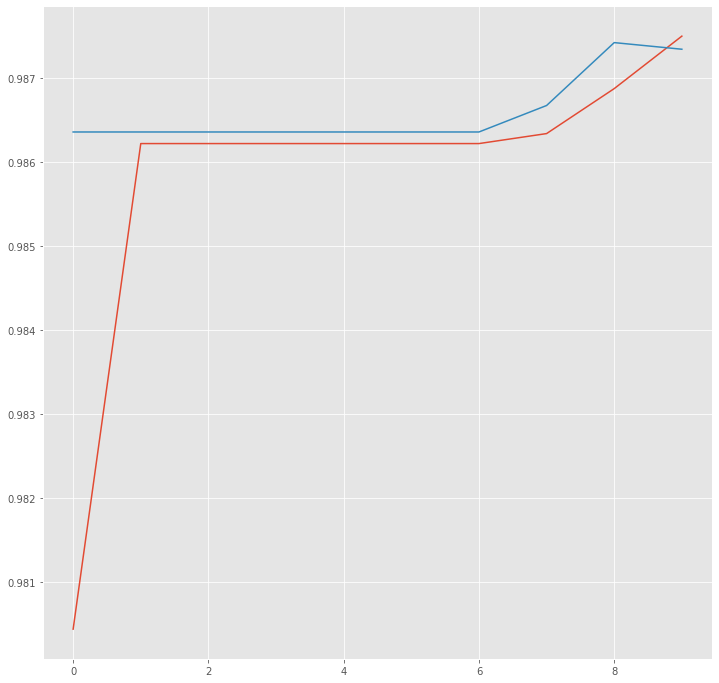

In [ ]:
import matplotlib.pyplot as plt
plt.style.use("ggplot")
plt.figure(figsize=(12,12))
plt.plot(hist["acc"])
plt.plot(hist["val_acc"])
plt.show()

In [ ]:
y_pred = model.predict([X_word_te,
                        np.array(X_char_te).reshape((len(X_char_te),
                                                     max_len, max_len_char))])

test the model to get f1-score

In [ ]:
list_true = list()
list_pred = list()

In [ ]:
num_of_sent = 1272
for i in range(num_of_sent):
  p = np.argmax(y_pred[i], axis=-1)
  for w, t, pred in zip(X_word_te[i], y_te[i], p):
    if w != 0:
      list_true.append(t)
      list_pred.append(pred)
print(len(list_true))
print(len(list_pred))

92940
92940


In [ ]:
print(list_pred)

[0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 

In [ ]:
from sklearn.metrics import f1_score

In [ ]:
f1_score(list_true, list_pred, pos_label = 1)

0.21375186846038863